In [1]:
import pandas as pd
import numpy as np
import ast # Para convertir cadenas de texto con formato de lista/diccionario a objetos de Python
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# Carga de DataFrames
try:
    # Carga del dataset principal de películas
    movies = pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv', low_memory=False)
    # Carga del dataset de créditos (reparto y equipo)
    credits = pd.read_csv('/content/drive/MyDrive/Archivos .csv/credits.csv')
    # Carga del Índice de Precios al Consumo (CPI) para ajustar la inflación
    cpi = pd.read_csv('/content/drive/MyDrive/Archivos .csv/CPI.csv')
    print("Archivos cargados correctamente.")
except FileNotFoundError:
    print("Asegúrate de que 'movies_metadata.csv', 'credits.csv' y 'CPI.csv' están en la ruta correcta.")

Archivos cargados correctamente.


In [3]:
## Limpieza y Conversión de la Columna 'id'

# La columna 'id' debe ser numérica para fusionar. Identificamos y eliminamos las filas no válidas.
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies.dropna(subset=['id'], inplace=True)
movies['id'] = movies['id'].astype(int)

# Hacemos lo mismo para la columna 'budget' para poder filtrar por ella.
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce').fillna(0)


## Fusión de DataFrames

# Renombramos la columna 'id' en 'credits' para que coincida con 'movies'
credits.rename(columns={'movie_id': 'id'}, inplace=True)

# Fusionamos los dos dataframes por la clave 'id'
df = pd.merge(movies, credits, on='id', how='inner')

# Seleccionamos solo las columnas que vamos a necesitar para simplificar el DataFrame
columnas_necesarias = [
    'id', 'title', 'genres', 'cast', 'crew', 'budget',
    'vote_average', 'vote_count', 'original_language', 'production_countries',
    'release_date', 'revenue' # revenue se mantiene por ahora, aunque luego no se use como feature
]
df = df[columnas_necesarias]

print(f"Número de películas después de la fusión: {len(df)}")

Número de películas después de la fusión: 45538


In [25]:
## Función de Extracción
def extract_names(json_string, key_to_extract):
    """Convierte una cadena JSON-like en una lista de valores de la clave especificada."""
    if pd.isna(json_string):
        return []
    try:
        # ast.literal_eval es más seguro que eval()
        list_of_dicts = ast.literal_eval(json_string)
        return [item[key_to_extract] for item in list_of_dicts]
    except (ValueError, TypeError):
        return []

## Aplicación de las Funciones

# Extraer Géneros
df['genres_list'] = df['genres'].apply(lambda x: extract_names(x, 'name'))

# Extraer Reparto (top 3 actores para simplificar el modelo)
def extract_top_cast(json_string, n=3):
    return extract_names(json_string, 'name')[:n]

df['cast_list'] = df['cast'].apply(lambda x: extract_top_cast(x))

# Extraer Director
def extract_director(crew_json):
    crew_list = extract_names(crew_json, 'job')
    names_list = extract_names(crew_json, 'name')
    if 'Director' in crew_list:
        # Encontrar el índice del director
        director_index = crew_list.index('Director')
        return names_list[director_index]
    return 'Unknown'

df['director'] = df['crew'].apply(extract_director)

# Mostrar el resultado de la extracción
print("\nEjemplo de la columna 'genres_list' y 'director':")
print(df[['title', 'genres_list', 'cast_list', 'director']].head())
df['genres_list'].head()


Ejemplo de la columna 'genres_list' y 'director':
                         title                   genres_list  \
0                    Toy Story   [Animation, Comedy, Family]   
1                      Jumanji  [Adventure, Fantasy, Family]   
2             Grumpier Old Men             [Romance, Comedy]   
3            Waiting to Exhale      [Comedy, Drama, Romance]   
4  Father of the Bride Part II                      [Comedy]   

                                           cast_list         director  
0                [Tom Hanks, Tim Allen, Don Rickles]    John Lasseter  
1     [Robin Williams, Jonathan Hyde, Kirsten Dunst]     Joe Johnston  
2         [Walter Matthau, Jack Lemmon, Ann-Margret]    Howard Deutch  
3  [Whitney Houston, Angela Bassett, Loretta Devine]  Forest Whitaker  
4         [Steve Martin, Diane Keaton, Martin Short]    Charles Shyer  


,genres_list
0,"[Animation, Comedy, Family]"
1,"[Adventure, Fantasy, Family]"
2,"[Romance, Comedy]"
3,"[Comedy, Drama, Romance]"
4,[Comedy]


In [24]:
## Filtrar por Budget (presupuesto)
df_filtrado = df[df['budget'] > 100000.0].copy()

## Filtrar por País de Producción o Idioma Original
# Convertir 'production_countries' para poder buscar 'United States of America'
df_filtrado['countries_list'] = df_filtrado['production_countries'].apply(lambda x: extract_names(x, 'iso_3166_1'))

# Definimos las condiciones de filtrado
is_american = df_filtrado['countries_list'].apply(lambda x: 'US' in x)
is_english = df_filtrado['original_language'] == 'en'

# Aplicamos el filtro: (Americanas O Idioma Inglés)
df_filtrado = df_filtrado[is_american | is_english].copy()
df_filtrado.to_csv('/content/drive/MyDrive/Archivos .csv/peliculas_creditos_filtrado.csv')
print(f"Número de películas después de aplicar todos los filtros: {len(df_filtrado)}")

Número de películas después de aplicar todos los filtros: 7042


In [6]:
## Definición de Variables

# v (Número de votos)
v = df_filtrado['vote_count']
# R (Rating)
R = df_filtrado['vote_average']
# m (Media del dataset)
m = df_filtrado['vote_average'].mean()
# C (Confianza): La mediana del número de votos (como umbral)
C = df_filtrado['vote_count'].median()

print(f"Media global de la puntuación (m): {m:.2f}")
print(f"Umbral de Confianza (C - mediana de votos): {C:.0f} votos")

## Cálculo de la Media Bayesiana
df_filtrado['weighted_rating'] = ((v * R) + (C * m)) / (v + C)

# El atributo objetivo a predecir
target_col = 'weighted_rating'

print("\nPrimeras 5 películas con su Rating Bayesiano:")
print(df_filtrado[['title', 'vote_average', 'vote_count', 'weighted_rating']].head())

Media global de la puntuación (m): 6.00
Umbral de Confianza (C - mediana de votos): 147 votos

Primeras 5 películas con su Rating Bayesiano:
               title  vote_average  vote_count  weighted_rating
0          Toy Story           7.7      5415.0         7.655105
1            Jumanji           6.9      2413.0         6.848397
3  Waiting to Exhale           6.1        34.0         6.019869
5               Heat           7.7      1886.0         7.577175
6            Sabrina           6.2       141.0         6.098598


In [7]:
## Procesamiento del CPI
cpi = pd.read_csv('/content/drive/MyDrive/Archivos .csv/CPI.csv')
cpi.columns = ['Year', 'CPI_Value', 'Annual Percent Change']
cpi['Year'] = cpi['Year'].astype(int)

# Encontramos el año base más reciente para el ajuste
year_base = cpi['Year'].max()
cpi_base = cpi[cpi['Year'] == year_base]['CPI_Value'].iloc[0]

# Función de Ajuste
def adjust_for_inflation(row, cpi_df, cpi_base, year_base):
    try:
        # Extraer el año de lanzamiento de la película
        year = int(row['release_date'].split('-')[0])

        if year < cpi_df['Year'].min() or year > year_base:
            return row['budget'] # No se puede ajustar si está fuera del rango de CPI

        # CPI del año de la película
        cpi_movie = cpi_df[cpi_df['Year'] == year]['CPI_Value'].iloc[0]

        # Fórmula de Ajuste: Budget_Ajustado = Budget_Original * (CPI_Base / CPI_Película)
        return row['budget'] * (cpi_base / cpi_movie)

    except:
        return row['budget']

## Aplicar el Ajuste
df_filtrado['budget_adjusted'] = df_filtrado.apply(lambda row: adjust_for_inflation(row, cpi, cpi_base, year_base), axis=1)

# Sustituir la columna original
df_filtrado['budget'] = df_filtrado['budget_adjusted']
df_filtrado.drop(columns=['budget_adjusted', 'revenue'], inplace=True) # Revenue no se usa

print("Presupuesto ajustado por inflación.")
print(df_filtrado[['title', 'release_date', 'budget']].head())

Presupuesto ajustado por inflación.
               title release_date        budget
0          Toy Story   1995-10-30  6.344488e+07
1            Jumanji   1995-12-15  1.374639e+08
3  Waiting to Exhale   1995-12-22  3.383727e+07
5               Heat   1995-12-15  1.268898e+08
6            Sabrina   1995-12-15  1.226601e+08


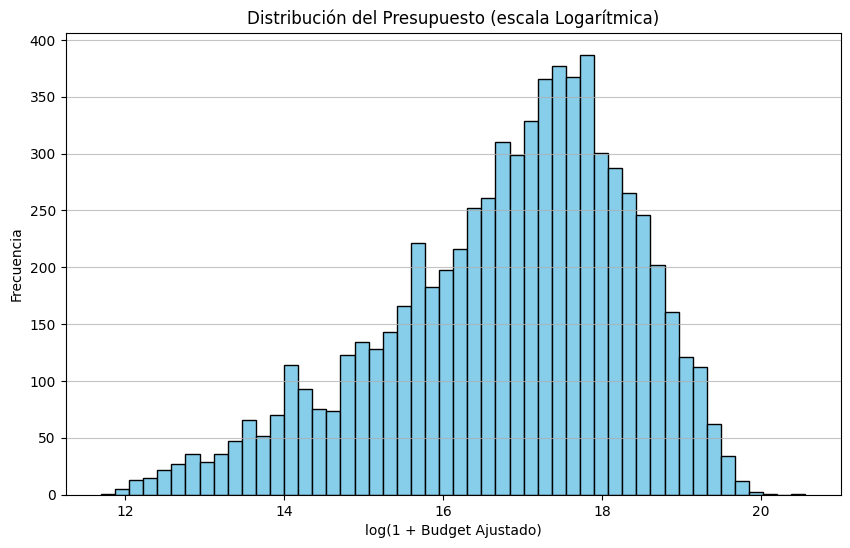

In [8]:
## Distribución del Budget
plt.figure(figsize=(10, 6))
# Usamos el logaritmo para manejar la gran dispersión del presupuesto
plt.hist(np.log1p(df_filtrado['budget']), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución del Presupuesto (escala Logarítmica)')
plt.xlabel('log(1 + Budget Ajustado)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

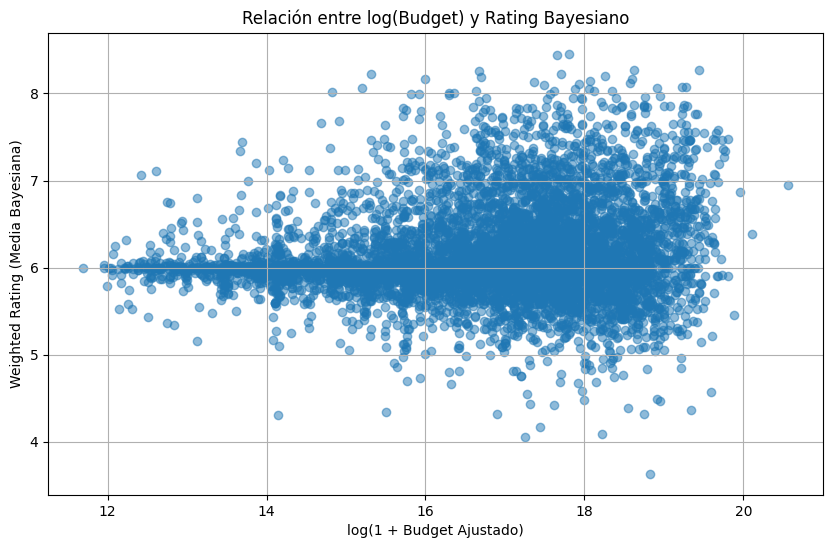


Conclusiones del análisis:
Budget: Muestra una gran dispersión (por eso se usa el logaritmo). La gráfica de dispersión sugiere una correlación positiva, aunque débil, entre un mayor presupuesto y un mejor rating.


In [9]:
## Relación entre Budget y Rating Bayesiano
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(df_filtrado['budget']), df_filtrado['weighted_rating'], alpha=0.5)
plt.title('Relación entre log(Budget) y Rating Bayesiano')
plt.xlabel('log(1 + Budget Ajustado)')
plt.ylabel('Weighted Rating (Media Bayesiana)')
plt.grid(True)
plt.show()

print("\nConclusiones del análisis:")
print("Budget: Muestra una gran dispersión (por eso se usa el logaritmo). La gráfica de dispersión sugiere una correlación positiva, aunque débil, entre un mayor presupuesto y un mejor rating.")

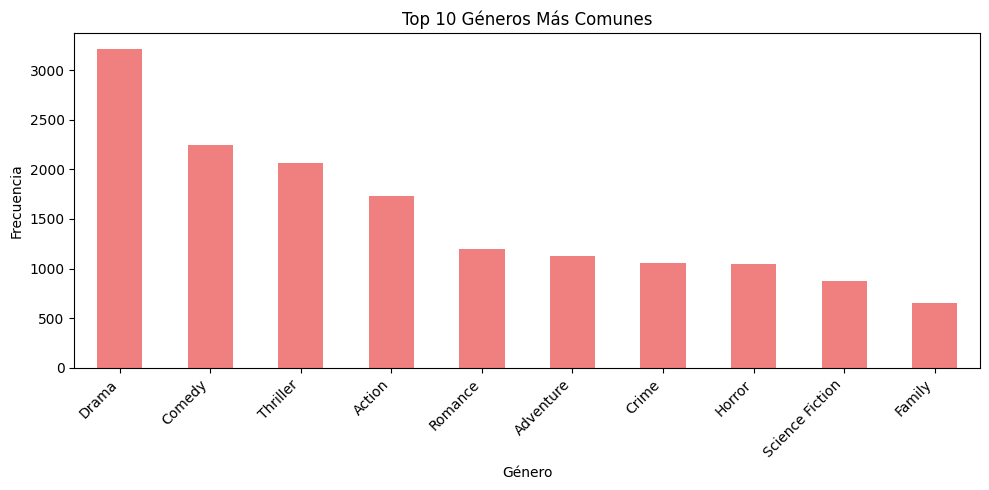

Géneros: Se observa la distribución de los géneros. Este tipo de variables categóricas requerirá una codificación (como One-Hot Encoding) para que el modelo las entienda.


In [10]:
# Análisis de las Variables Categóricas (Ejemplo: Géneros)

# Contar cuántas veces aparece cada género
all_genres = [genre for sublist in df_filtrado['genres_list'] for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(10, 5))
genre_counts.plot(kind='bar', color='lightcoral')
plt.title('Top 10 Géneros Más Comunes')
plt.ylabel('Frecuencia')
plt.xlabel('Género')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print(f"Géneros: Se observa la distribución de los géneros. Este tipo de variables categóricas requerirá una codificación (como One-Hot Encoding) para que el modelo las entienda.")

In [11]:
# Creamos tramos de Budget. Usamos el logaritmo porque la distribución es asimétrica.
df_filtrado['budget_log'] = np.log1p(df_filtrado['budget'])
# Dividimos los valores logarítmicos en 5 categorías (estratos)
df_filtrado['budget_cat'] = pd.cut(
    df_filtrado['budget_log'],
    bins=5,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

print("Distribución de películas por categoría de presupuesto (estrato):")
print(df_filtrado['budget_cat'].value_counts(normalize=True).sort_index())

Distribución de películas por categoría de presupuesto (estrato):
budget_cat
1    0.032803
2    0.131923
3    0.319369
4    0.444050
5    0.071855
Name: proportion, dtype: float64


In [12]:
## Separación Estratificada
# Usamos StratifiedShuffleSplit para asegurar que la proporción de cada estrato sea similar en train y test.
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df_filtrado, df_filtrado['budget_cat']):
    df_train = df_filtrado.iloc[train_index].copy()
    df_test = df_filtrado.iloc[test_index].copy()

# Verificamos que la columna 'budget_cat' ya no es necesaria en los sets
df_train.drop(columns=['budget_log', 'budget_cat'], inplace=True)
df_test.drop(columns=['budget_log', 'budget_cat'], inplace=True)

print(f"\nConjunto de Entrenamiento (Train): {len(df_train)} películas")
print(f"Conjunto de Validación (Test): {len(df_test)} películas")


Conjunto de Entrenamiento (Train): 5633 películas
Conjunto de Validación (Test): 1409 películas


In [13]:
# Definición de X (Features) e y (Target)
X_train = df_train[['budget', 'genres_list', 'cast_list', 'director']]
y_train = df_train[target_col]

X_test = df_test[['budget', 'genres_list', 'cast_list', 'director']]
y_test = df_test[target_col]

In [14]:
# Preparación de las Features Categóricas para One-Hot Encoding

# NOTA: OneHotEncoder de sklearn no maneja listas directamente.
# La estrategia más simple es tomar los 10 valores más frecuentes de cada feature y crear una columna para cada uno.

def get_top_features(series_list, n=10):
    """Devuelve los n valores más frecuentes en una lista de listas/valores."""
    all_items = [item for sublist in series_list for item in (sublist if isinstance(sublist, list) else [sublist])]
    return pd.Series(all_items).value_counts().head(n).index.tolist()

# Seleccionamos los top 10 de cada feature
top_genres = get_top_features(X_train['genres_list'], 10)
top_cast = get_top_features(X_train['cast_list'], 10)
top_directors = get_top_features(X_train['director'], 10)

# Lista de todas las categorías consideradas (para el OneHotEncoder)
all_categories = [top_genres, top_cast, top_directors]

In [15]:
# Creamos un DataFrame que transforma las listas en columnas One-Hot para el Pipeline
def list_to_bool_df(df, feature_col, categories):
    """Crea columnas booleanas (dummies) para cada elemento en la lista."""
    data = {}
    for cat in categories:
        # Crea una columna booleana (1 o 0 / True o False) si la categoría está en la lista de la fila
        data[f'{feature_col}_{cat}'] = df[feature_col].apply(lambda x: cat in x)
    return pd.DataFrame(data, index=df.index)

# Creamos los DataFrames con las features transformadas (Train)
X_train_processed = pd.concat([
    X_train.drop(columns=['genres_list', 'cast_list', 'director']),
    list_to_bool_df(X_train, 'genres_list', top_genres),
    list_to_bool_df(X_train, 'cast_list', top_cast),
    pd.get_dummies(X_train['director'].apply(lambda x: x if x in top_directors else 'Other'))
], axis=1)

# Creamos los DataFrames con las features transformadas (Test)
X_test_processed = pd.concat([
    X_test.drop(columns=['genres_list', 'cast_list', 'director']),
    list_to_bool_df(X_test, 'genres_list', top_genres),
    list_to_bool_df(X_test, 'cast_list', top_cast),
    pd.get_dummies(X_test['director'].apply(lambda x: x if x in top_directors else 'Other'))
], axis=1)

In [16]:
# Aseguramos que ambos DataFrames tengan las mismas columnas (especialmente para los directores 'Other')
missing_cols = set(X_train_processed.columns) - set(X_test_processed.columns)
for c in missing_cols:
    X_test_processed[c] = False
X_test_processed = X_test_processed[X_train_processed.columns]

# Definición de las columnas para el escalado
numerical_features = ['budget']
# El resto de las columnas son las categóricas (One-Hot)
categorical_features = [col for col in X_train_processed.columns if col != 'budget']

# Creamos el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # Escalado para Budget
        # Las features categóricas ya están en formato booleano/numérico (0/1), por lo que no requieren más transformación aquí
    ],
    remainder='passthrough' # Mantiene las columnas categóricas ya procesadas
)

print(f"Dimensiones del set de entrenamiento preprocesado (X): {X_train_processed.shape}")
print(f"Columnas finales de features: {X_train_processed.columns.tolist()}")

Dimensiones del set de entrenamiento preprocesado (X): (5633, 32)
Columnas finales de features: ['budget', 'genres_list_Drama', 'genres_list_Comedy', 'genres_list_Thriller', 'genres_list_Action', 'genres_list_Romance', 'genres_list_Adventure', 'genres_list_Horror', 'genres_list_Crime', 'genres_list_Science Fiction', 'genres_list_Family', 'cast_list_Nicolas Cage', 'cast_list_Robert De Niro', 'cast_list_Bruce Willis', 'cast_list_Samuel L. Jackson', 'cast_list_Johnny Depp', 'cast_list_Sylvester Stallone', 'cast_list_Morgan Freeman', 'cast_list_Meryl Streep', 'cast_list_Eddie Murphy', 'cast_list_Matt Damon', 'Alfred Hitchcock', 'Clint Eastwood', 'Martin Scorsese', 'Oliver Stone', 'Other', 'Ridley Scott', 'Steven Soderbergh', 'Steven Spielberg', 'Tim Burton', 'Unknown', 'Woody Allen']


In [17]:
## Regresión Lineal (Linear Regression)
print("Regresión Lineal")
# Creamos el Pipeline: Preprocesador -> Modelo
lin_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', LinearRegression())])

# Entrenamos el modelo
lin_reg_pipeline.fit(X_train_processed, y_train)

# Predicciones
y_pred_lr = lin_reg_pipeline.predict(X_test_processed)

# Evaluación
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Error Cuadrático Medio (RMSE): {rmse_lr:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_lr:.4f}")

Regresión Lineal
Error Cuadrático Medio (RMSE): 0.4828
Coeficiente de Determinación (R²): 0.1405


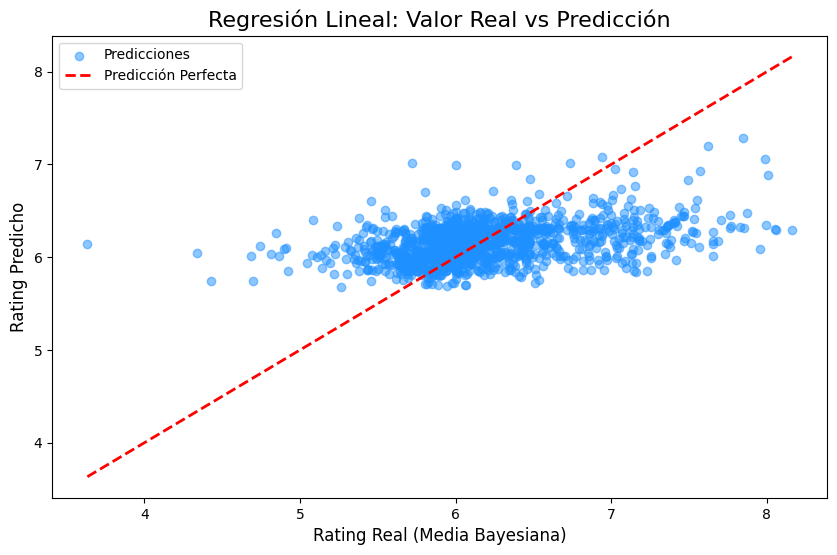

In [18]:
## Gráfico de Regresión Lineal (Predicción vs. Real)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='dodgerblue', label='Predicciones')
# Línea roja de referencia (donde la predicción sería perfecta: y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')

plt.title('Regresión Lineal: Valor Real vs Predicción', fontsize=16)
plt.xlabel('Rating Real (Media Bayesiana)', fontsize=12)
plt.ylabel('Rating Predicho', fontsize=12)
plt.legend()
plt.show()

In [19]:
## Random Forest (Random Forest Regressor)
print("\nRandom Forest")
# Creamos el Pipeline: Preprocesador -> Modelo
# Usamos un número razonable de estimadores para empezar
rf_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

# Entrenamos el modelo
rf_reg_pipeline.fit(X_train_processed, y_train)

# Predicciones
y_pred_rf = rf_reg_pipeline.predict(X_test_processed)

# Evaluación
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Error Cuadrático Medio (RMSE): {rmse_rf:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_rf:.4f}")


Random Forest
Error Cuadrático Medio (RMSE): 0.5476
Coeficiente de Determinación (R²): -0.1059


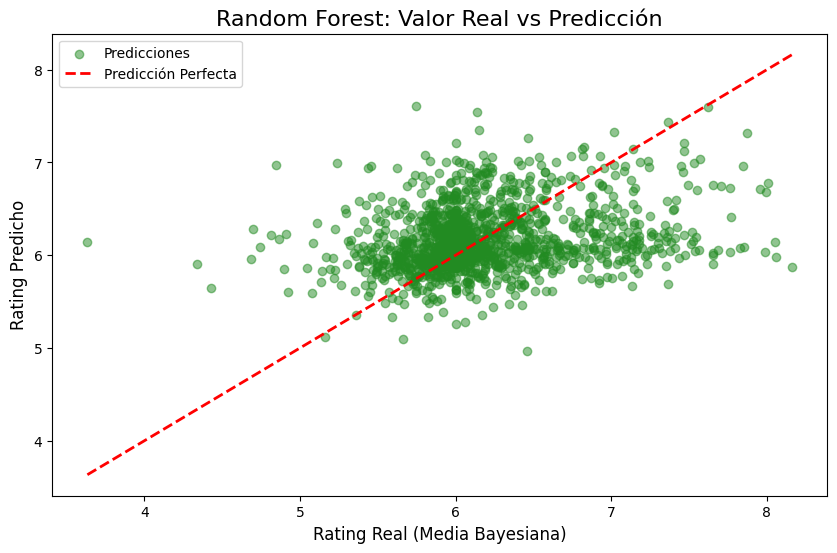

In [20]:
## Gráfico de Random Forest (Predicción vs. Real)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='forestgreen', label='Predicciones')
# Línea roja de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')

plt.title('Random Forest: Valor Real vs Predicción', fontsize=16)
plt.xlabel('Rating Real (Media Bayesiana)', fontsize=12)
plt.ylabel('Rating Predicho', fontsize=12)
plt.legend()
plt.show()

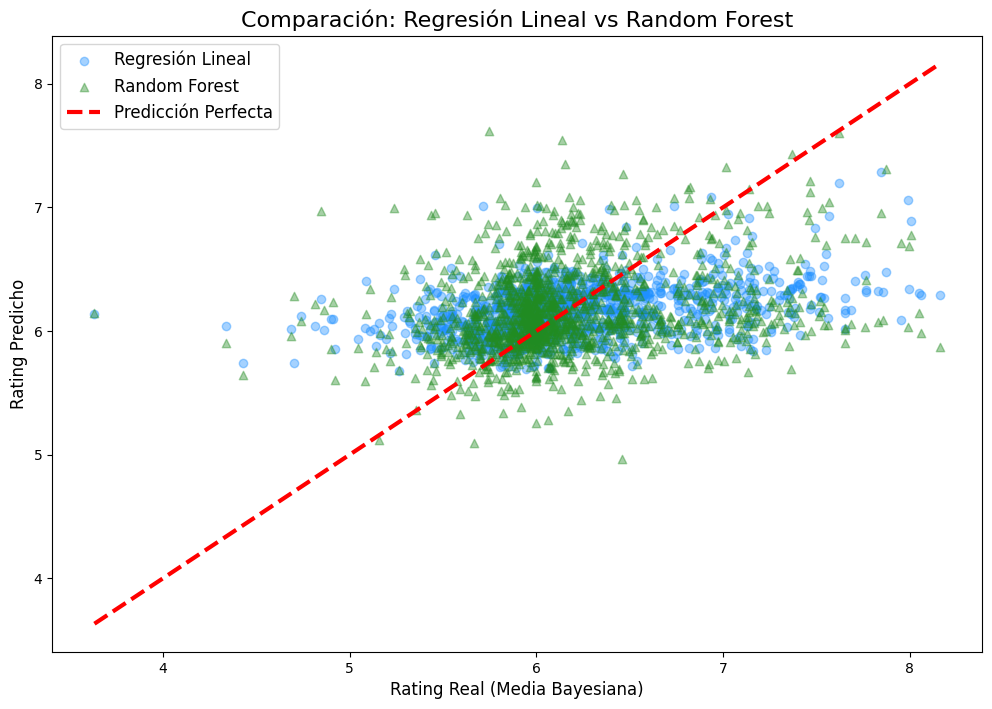

In [21]:
## Gráfico comparativo de ambos modelos
plt.figure(figsize=(12, 8))

# Pintamos ambos: usamos marcadores distintos para diferenciarlos
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='dodgerblue', marker='o', label='Regresión Lineal')
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='forestgreen', marker='^', label='Random Forest')

# Línea de referencia
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Predicción Perfecta')

plt.title('Comparación: Regresión Lineal vs Random Forest', fontsize=16)
plt.xlabel('Rating Real (Media Bayesiana)', fontsize=12)
plt.ylabel('Rating Predicho', fontsize=12)
plt.legend(fontsize=12)
plt.show()